<a href="https://colab.research.google.com/github/Goodday202007/AIFFEL_quest_eng/blob/main/Main_Quest/Quest01/MainQuest1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Main Quest 1 - Spaceship Titanic

Kaggle 에 있는 Spaceship Titanic 데이타를 이용한 테스트

target data는 Transported로 boolean 값이다

결측치 및 다양한 형태의 데이타로 데이타 전처리가 중요합니다.

Spaceship Titanic : https://www.kaggle.com/competitions/spaceship-titanic

# 1. 라이브러리, 데이터 가져오기

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
from os.path import join

import pandas as pd
import numpy as np

import missingno as msno

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import seaborn as sns

print('얍💢')

얍💢


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# 현재 작업 디렉토리 확인
print(f"현재 작업 디렉토리: {os.getcwd()}")

# Google Drive 내용 확인 (옵션)
# 'Colab Notebooks' 폴더가 '/content/drive' 바로 아래에 있다고 가정합니다.
# 만약 다른 경로에 있다면, 아래 명령어로 확인 후 경로를 수정해야 합니다.
!ls /content/drive

현재 작업 디렉토리: /content
MyDrive


In [5]:
import os

# 'Colab Notebooks' 폴더로 작업 디렉토리 변경
# 이 경로가 맞지 않으면 FileNotFoundError가 발생할 수 있습니다.
# 실제 경로에 맞춰 'Colab Notebooks' 부분을 수정해주세요.
notebooks_path = '/content/drive/MyDrive/Colab Notebooks/2025.12-26.6_AIFFEL/Data_Analysis' # 일반적인 Google Drive Colab Notebooks 경로

# 폴더가 존재하지 않으면 생성할 수 있습니다 (선택 사항)
# if not os.path.exists(notebooks_path):
#     os.makedirs(notebooks_path)

os.chdir(notebooks_path)

# 변경된 작업 디렉토리 확인
print(f"새로운 작업 디렉토리: {os.getcwd()}")

새로운 작업 디렉토리: /content/drive/MyDrive/Colab Notebooks/2025.12-26.6_AIFFEL/Data_Analysis


In [6]:
# 데이타 로딩

train_data_path = 'train.csv'
test_data_path = 'test.csv'

train = pd.read_csv(train_data_path)
test = pd.read_csv(test_data_path)

print('얍💢')

얍💢


# 2. 데이터 살펴보기, 피쳐 엔지니어링

In [ ]:
train.shape

(8693, 14)

In [ ]:
test.shape

(4277, 13)

### File and Data Field Descriptions

#### train.csv - Personal records for about two-thirds (~8700) of the passengers, to be used as training data.

- PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.
- HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.
- CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
- Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
- Destination - The planet the passenger will be debarking to.
- Age - The age of the passenger.
- VIP - Whether the passenger has paid for special VIP service during the voyage.
- RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
Name - The first and last names of the passenger.
- Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

#### test.csv - Personal records for the remaining one-third (~4300) of the passengers, to be used as test data. Your task is to predict the value of Transported for the passengers in this set.

#### sample_submission.csv - A submission file in the correct format.
- PassengerId - Id for each passenger in the test set.
- Transported - The target. For each passenger, predict either True or False.

In [ ]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [7]:
# train 에서 y 별도 저장후 삭제 (LGBMClassifier 진행을 위해 0, 1로 변환)

y = train['Transported'].map({
        True: 1, False: 0,
        'True': 1, 'False': 0
    })

del train['Transported']

y.head()

,Transported
0,0
1,1
2,0
3,0
4,1


In [ ]:
print(train.columns)

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name'],
      dtype='object')


In [8]:
# 학습 데이터와 테스트 데이터 합치기

train_len = len(train)
data = pd.concat((train, test), axis=0)

print(len(data))

12970


In [ ]:
8693 + 4277


12970

<Axes: >

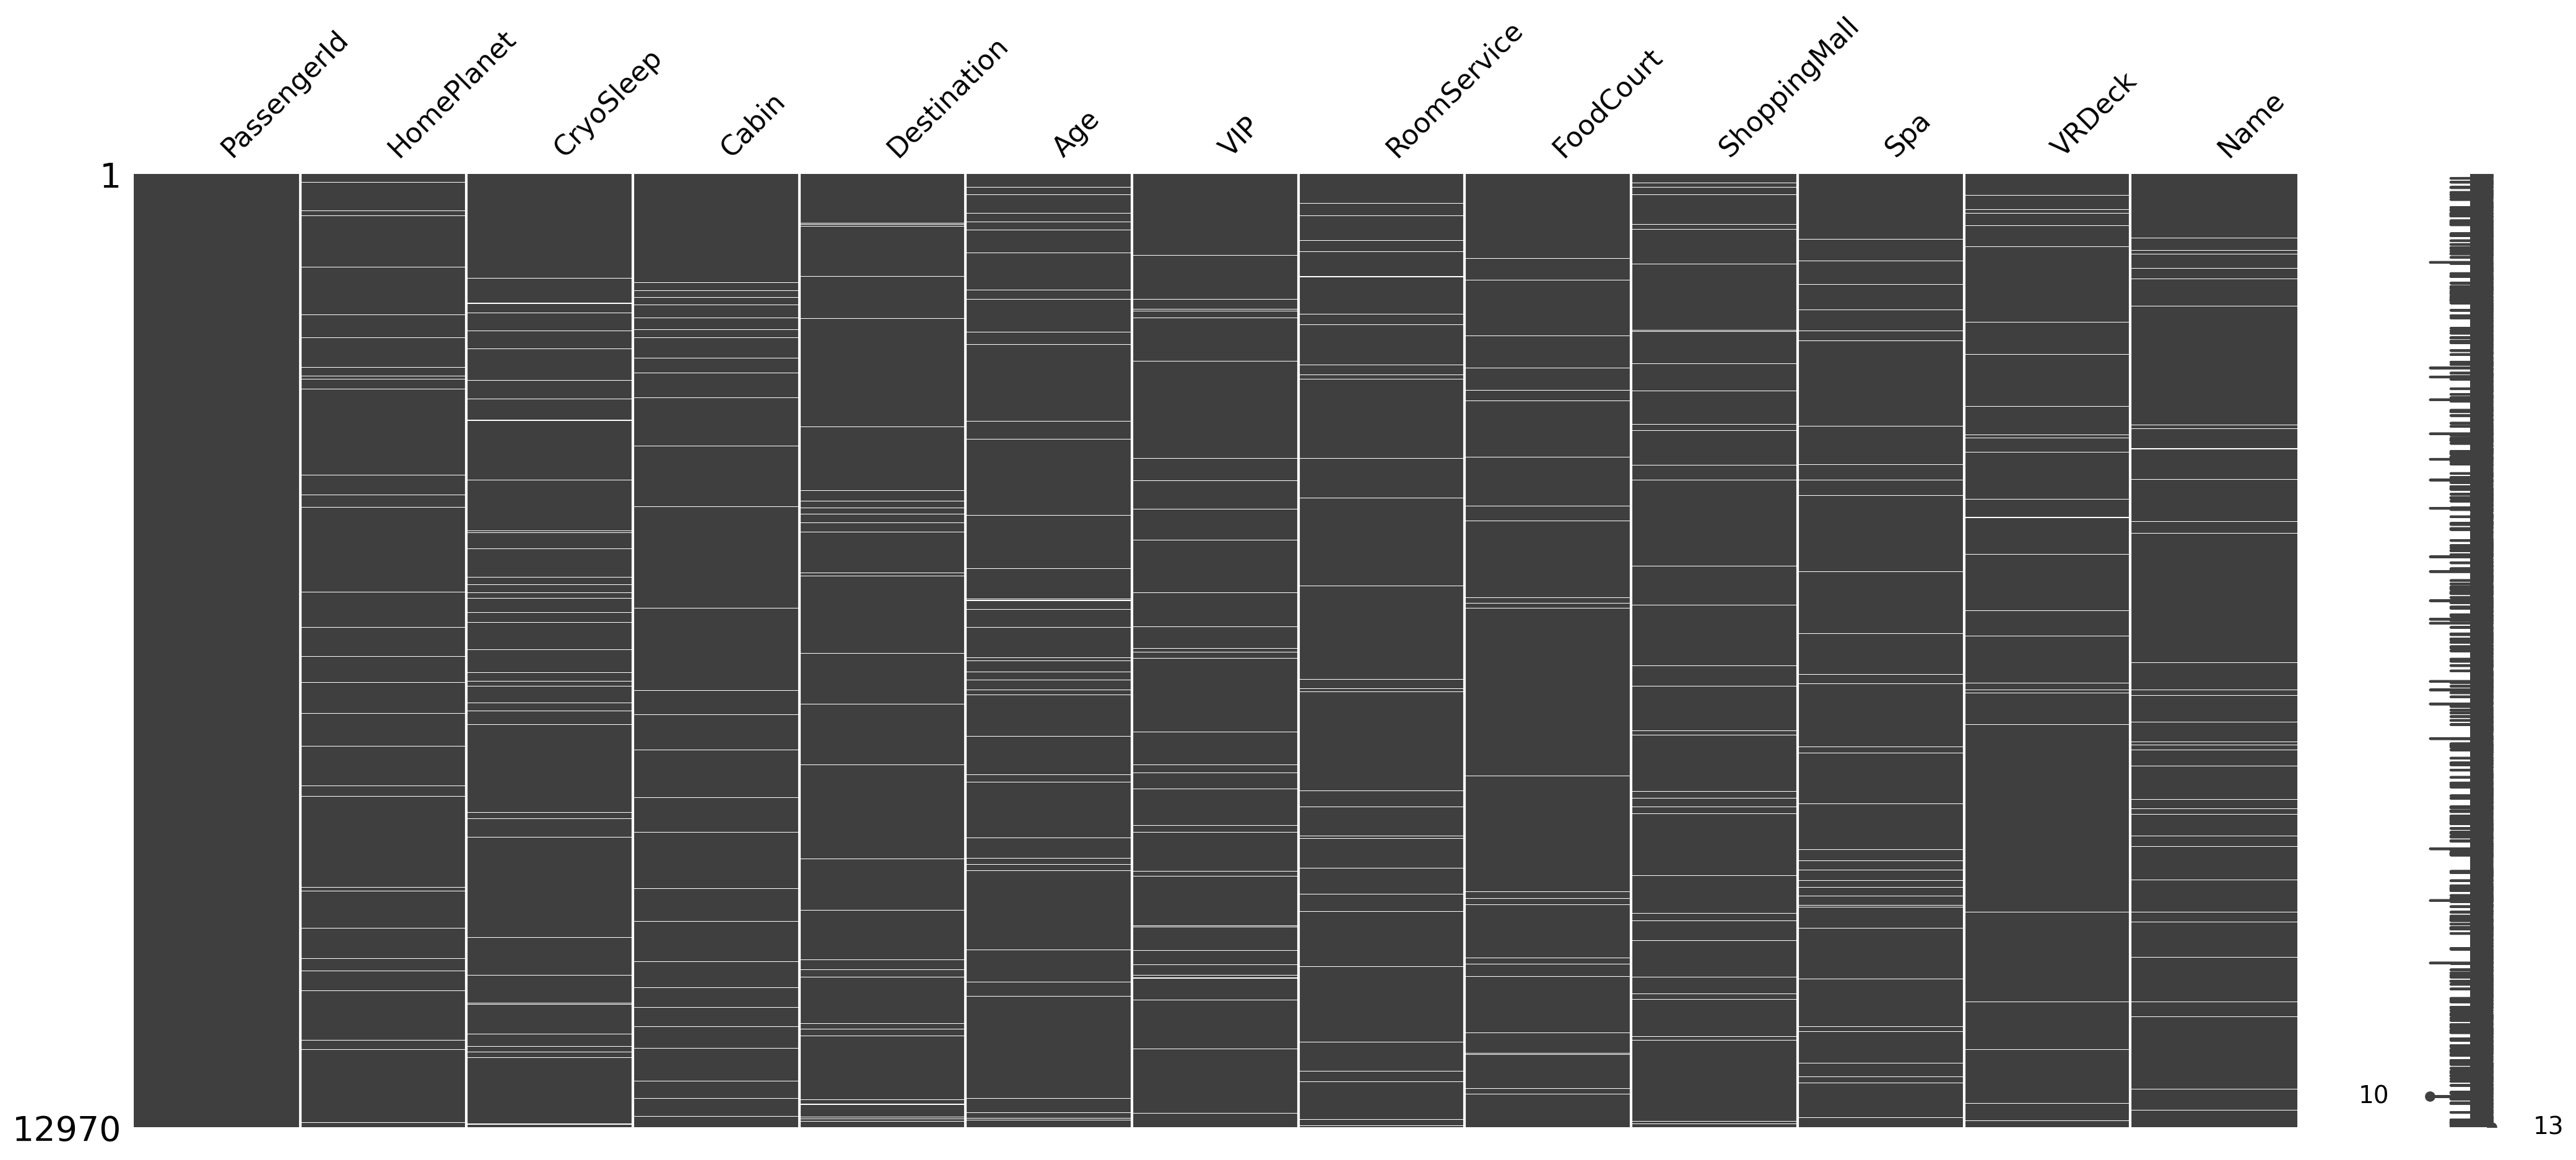

In [ ]:
# 결측치 확인

msno.matrix(data)

In [ ]:
for c in data.columns:
    print('{} : {}'.format(c, len(data.loc[pd.isnull(data[c]), c].values)))

PassengerId : 0
HomePlanet : 288
CryoSleep : 310
Cabin : 299
Destination : 274
Age : 270
VIP : 296
RoomService : 263
FoodCourt : 289
ShoppingMall : 306
Spa : 284
VRDeck : 268
Name : 294


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12970 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   12970 non-null  object 
 1   HomePlanet    12682 non-null  object 
 2   CryoSleep     12660 non-null  object 
 3   Cabin         12671 non-null  object 
 4   Destination   12696 non-null  object 
 5   Age           12700 non-null  float64
 6   VIP           12674 non-null  object 
 7   RoomService   12707 non-null  float64
 8   FoodCourt     12681 non-null  float64
 9   ShoppingMall  12664 non-null  float64
 10  Spa           12686 non-null  float64
 11  VRDeck        12702 non-null  float64
 12  Name          12676 non-null  object 
dtypes: float64(6), object(7)
memory usage: 1.4+ MB


#### 결측치 가 많고 데이타 특성이 다양해서 수치화를 위해 피쳐 엔지니어닝 진행

In [ ]:
data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines


In [9]:
# 작업용 데이타 생성

data_copy = data.copy()

In [10]:
# Boolean 데이타 변경

for col in ['CryoSleep', 'VIP']:
    data_copy[col] = data_copy[col].map({
        True: 1, False: 0,
        'True': 1, 'False': 0
    })

In [11]:
data_copy.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0001_01,Europa,0.0,B/0/P,TRAPPIST-1e,39.0,0.0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy
1,0002_01,Earth,0.0,F/0/S,TRAPPIST-1e,24.0,0.0,109.0,9.0,25.0,549.0,44.0,Juanna Vines
2,0003_01,Europa,0.0,A/0/S,TRAPPIST-1e,58.0,1.0,43.0,3576.0,0.0,6715.0,49.0,Altark Susent
3,0003_02,Europa,0.0,A/0/S,TRAPPIST-1e,33.0,0.0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent
4,0004_01,Earth,0.0,F/1/S,TRAPPIST-1e,16.0,0.0,303.0,70.0,151.0,565.0,2.0,Willy Santantines


In [12]:
# 범주형 컬럼 → Label Encoding

data_copy['HomePlanet'].unique()

array(['Europa', 'Earth', 'Mars', nan], dtype=object)

In [13]:
data_copy['Destination'].unique()

array(['TRAPPIST-1e', 'PSO J318.5-22', '55 Cancri e', nan], dtype=object)

In [14]:
from sklearn.preprocessing import LabelEncoder

for col in ['HomePlanet', 'Destination']:
    data_copy[col] = data_copy[col].fillna('Unknown')
    data_copy[col] = LabelEncoder().fit_transform(data_copy[col])


In [15]:
data_copy.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0001_01,1,0.0,B/0/P,2,39.0,0.0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy
1,0002_01,0,0.0,F/0/S,2,24.0,0.0,109.0,9.0,25.0,549.0,44.0,Juanna Vines
2,0003_01,1,0.0,A/0/S,2,58.0,1.0,43.0,3576.0,0.0,6715.0,49.0,Altark Susent
3,0003_02,1,0.0,A/0/S,2,33.0,0.0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent
4,0004_01,0,0.0,F/1/S,2,16.0,0.0,303.0,70.0,151.0,565.0,2.0,Willy Santantines


In [16]:
data_copy['HomePlanet'].unique()

array([1, 0, 2, 3])

In [17]:
data_copy['Destination'].unique()

array([2, 1, 0, 3])

In [18]:
# Cabin 안에 있는 Deck / Num / Side 분해

data_copy[['Deck', 'CabinNum', 'Side']] = data_copy['Cabin'].str.split('/', expand=True)

In [19]:
data_copy.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Deck,CabinNum,Side
0,0001_01,1,0.0,B/0/P,2,39.0,0.0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,B,0,P
1,0002_01,0,0.0,F/0/S,2,24.0,0.0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,F,0,S
2,0003_01,1,0.0,A/0/S,2,58.0,1.0,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,A,0,S
3,0003_02,1,0.0,A/0/S,2,33.0,0.0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,A,0,S
4,0004_01,0,0.0,F/1/S,2,16.0,0.0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,F,1,S


In [20]:
data_copy['Deck'].unique()

array(['B', 'F', 'A', 'G', nan, 'E', 'D', 'C', 'T'], dtype=object)

In [21]:
data_copy['CabinNum'].unique()

array(['0', '1', '2', ..., '1885', '1887', '1890'], dtype=object)

In [22]:
data_copy['Side'].unique()

array(['P', 'S', nan], dtype=object)

In [23]:
# CabinNum 숫자화

data_copy['CabinNum'] = pd.to_numeric(data_copy['CabinNum'], errors='coerce')

In [24]:
# Deck, Side 에 대해 결측치 처리 및 Label Encoding

data_copy['Deck'] = data_copy['Deck'].fillna('Unknown')
data_copy['Side'] = data_copy['Side'].fillna('Unknown')

for col in ['Deck', 'Side']:
    data_copy[col] = LabelEncoder().fit_transform(data_copy[col])

In [25]:
data_copy.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Deck,CabinNum,Side
0,0001_01,1,0.0,B/0/P,2,39.0,0.0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,1,0.0,0
1,0002_01,0,0.0,F/0/S,2,24.0,0.0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,5,0.0,1
2,0003_01,1,0.0,A/0/S,2,58.0,1.0,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0,0.0,1
3,0003_02,1,0.0,A/0/S,2,33.0,0.0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0,0.0,1
4,0004_01,0,0.0,F/1/S,2,16.0,0.0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,5,1.0,1


In [26]:
# Cabin 컬럼 제거

data_copy.drop(columns=['Cabin'], inplace=True)

In [ ]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12970 entries, 0 to 4276
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   12970 non-null  object 
 1   HomePlanet    12970 non-null  int64  
 2   CryoSleep     12660 non-null  float64
 3   Destination   12970 non-null  int64  
 4   Age           12700 non-null  float64
 5   VIP           12674 non-null  float64
 6   RoomService   12707 non-null  float64
 7   FoodCourt     12681 non-null  float64
 8   ShoppingMall  12664 non-null  float64
 9   Spa           12686 non-null  float64
 10  VRDeck        12702 non-null  float64
 11  Name          12676 non-null  object 
 12  Deck          12970 non-null  int64  
 13  CabinNum      12671 non-null  float64
 14  Side          12970 non-null  int64  
dtypes: float64(9), int64(4), object(2)
memory usage: 1.6+ MB


In [27]:
# PassengerId → Group 정보 추출

data_copy['GroupId'] = data_copy['PassengerId'].str.split('_').str[0]
data_copy['GroupSize'] = data_copy.groupby('GroupId')['GroupId'].transform('count')

In [28]:
data_copy.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Deck,CabinNum,Side,GroupId,GroupSize
0,0001_01,1,0.0,2,39.0,0.0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,1,0.0,0,0001,1
1,0002_01,0,0.0,2,24.0,0.0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,5,0.0,1,0002,1
2,0003_01,1,0.0,2,58.0,1.0,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0,0.0,1,0003,2
3,0003_02,1,0.0,2,33.0,0.0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0,0.0,1,0003,2
4,0004_01,0,0.0,2,16.0,0.0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,5,1.0,1,0004,1


In [29]:
data_copy.drop(columns=['PassengerId', 'GroupId'], inplace=True)

In [30]:
data_copy.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Deck,CabinNum,Side,GroupSize
0,1,0.0,2,39.0,0.0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,1,0.0,0,1
1,0,0.0,2,24.0,0.0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,5,0.0,1,1
2,1,0.0,2,58.0,1.0,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0,0.0,1,2
3,1,0.0,2,33.0,0.0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0,0.0,1,2
4,0,0.0,2,16.0,0.0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,5,1.0,1,1


In [31]:
# Name → 가족 정보 추출

data_copy['LastName'] = data_copy['Name'].str.split(' ').str[-1]
data_copy['FamilySize'] = data_copy.groupby('LastName')['LastName'].transform('count')

In [32]:
data_copy.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Deck,CabinNum,Side,GroupSize,LastName,FamilySize
0,1,0.0,2,39.0,0.0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,1,0.0,0,1,Ofracculy,3.0
1,0,0.0,2,24.0,0.0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,5,0.0,1,1,Vines,4.0
2,1,0.0,2,58.0,1.0,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0,0.0,1,2,Susent,7.0
3,1,0.0,2,33.0,0.0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0,0.0,1,2,Susent,7.0
4,0,0.0,2,16.0,0.0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,5,1.0,1,1,Santantines,9.0


In [33]:
data_copy.drop(columns=['Name', 'LastName'], inplace=True)

In [34]:
data_copy.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,CabinNum,Side,GroupSize,FamilySize
0,1,0.0,2,39.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,0,1,3.0
1,0,0.0,2,24.0,0.0,109.0,9.0,25.0,549.0,44.0,5,0.0,1,1,4.0
2,1,0.0,2,58.0,1.0,43.0,3576.0,0.0,6715.0,49.0,0,0.0,1,2,7.0
3,1,0.0,2,33.0,0.0,0.0,1283.0,371.0,3329.0,193.0,0,0.0,1,2,7.0
4,0,0.0,2,16.0,0.0,303.0,70.0,151.0,565.0,2.0,5,1.0,1,1,9.0


In [35]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12970 entries, 0 to 4276
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    12970 non-null  int64  
 1   CryoSleep     12660 non-null  float64
 2   Destination   12970 non-null  int64  
 3   Age           12700 non-null  float64
 4   VIP           12674 non-null  float64
 5   RoomService   12707 non-null  float64
 6   FoodCourt     12681 non-null  float64
 7   ShoppingMall  12664 non-null  float64
 8   Spa           12686 non-null  float64
 9   VRDeck        12702 non-null  float64
 10  Deck          12970 non-null  int64  
 11  CabinNum      12671 non-null  float64
 12  Side          12970 non-null  int64  
 13  GroupSize     12970 non-null  int64  
 14  FamilySize    12676 non-null  float64
dtypes: float64(10), int64(5)
memory usage: 1.6 MB


In [36]:
# 결측치 확인

for c in data_copy.columns:
    print('{} : {}'.format(c, len(data_copy.loc[pd.isnull(data_copy[c]), c].values)))

HomePlanet : 0
CryoSleep : 310
Destination : 0
Age : 270
VIP : 296
RoomService : 263
FoodCourt : 289
ShoppingMall : 306
Spa : 284
VRDeck : 268
Deck : 0
CabinNum : 299
Side : 0
GroupSize : 0
FamilySize : 294


In [37]:
# 수치형 컬럼의 결측치 처리 (나이, 소비 금액 등이어서 0으로 처리)

num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

data_copy[num_cols] = data_copy[num_cols].fillna(0)

In [38]:
data_copy.isna().sum()

,0
HomePlanet,0
CryoSleep,310
Destination,0
Age,0
VIP,296
RoomService,0
FoodCourt,0
ShoppingMall,0
Spa,0
VRDeck,0


In [39]:
# 나머지 데이타 결측치 처리

for col in ['CryoSleep', 'VIP', 'CabinNum']:
    data_copy[col] = data_copy[col].fillna(-1)

data_copy['FamilySize'] = data_copy['FamilySize'].fillna(1)

In [40]:
data_copy.isna().sum()

,0
HomePlanet,0
CryoSleep,0
Destination,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0
Spa,0
VRDeck,0


In [41]:
# 룸서비스, 푸드코트, 쇼핑몰, 스파, VR덱)에서 발생한 소비 금액에 대해 추가 컬럼 생성 (소비 전체금액 항목 추가)

data_copy['TotalSpend'] = data_copy[['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']].sum(axis=1)

In [42]:
data_copy.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,CabinNum,Side,GroupSize,FamilySize,TotalSpend
0,1,0.0,2,39.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,0,1,3.0,0.0
1,0,0.0,2,24.0,0.0,109.0,9.0,25.0,549.0,44.0,5,0.0,1,1,4.0,736.0
2,1,0.0,2,58.0,1.0,43.0,3576.0,0.0,6715.0,49.0,0,0.0,1,2,7.0,10383.0
3,1,0.0,2,33.0,0.0,0.0,1283.0,371.0,3329.0,193.0,0,0.0,1,2,7.0,5176.0
4,0,0.0,2,16.0,0.0,303.0,70.0,151.0,565.0,2.0,5,1.0,1,1,9.0,1091.0


In [ ]:
data_copy.shape

(12970, 16)

In [ ]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12970 entries, 0 to 4276
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    12970 non-null  int64  
 1   CryoSleep     12970 non-null  float64
 2   Destination   12970 non-null  int64  
 3   Age           12970 non-null  float64
 4   VIP           12970 non-null  float64
 5   RoomService   12970 non-null  float64
 6   FoodCourt     12970 non-null  float64
 7   ShoppingMall  12970 non-null  float64
 8   Spa           12970 non-null  float64
 9   VRDeck        12970 non-null  float64
 10  Deck          12970 non-null  int64  
 11  CabinNum      12970 non-null  float64
 12  Side          12970 non-null  int64  
 13  GroupSize     12970 non-null  int64  
 14  FamilySize    12970 non-null  float64
 15  TotalSpend    12970 non-null  float64
dtypes: float64(11), int64(5)
memory usage: 1.7 MB


In [43]:
data_copy.isna().sum()

,0
HomePlanet,0
CryoSleep,0
Destination,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0
Spa,0
VRDeck,0


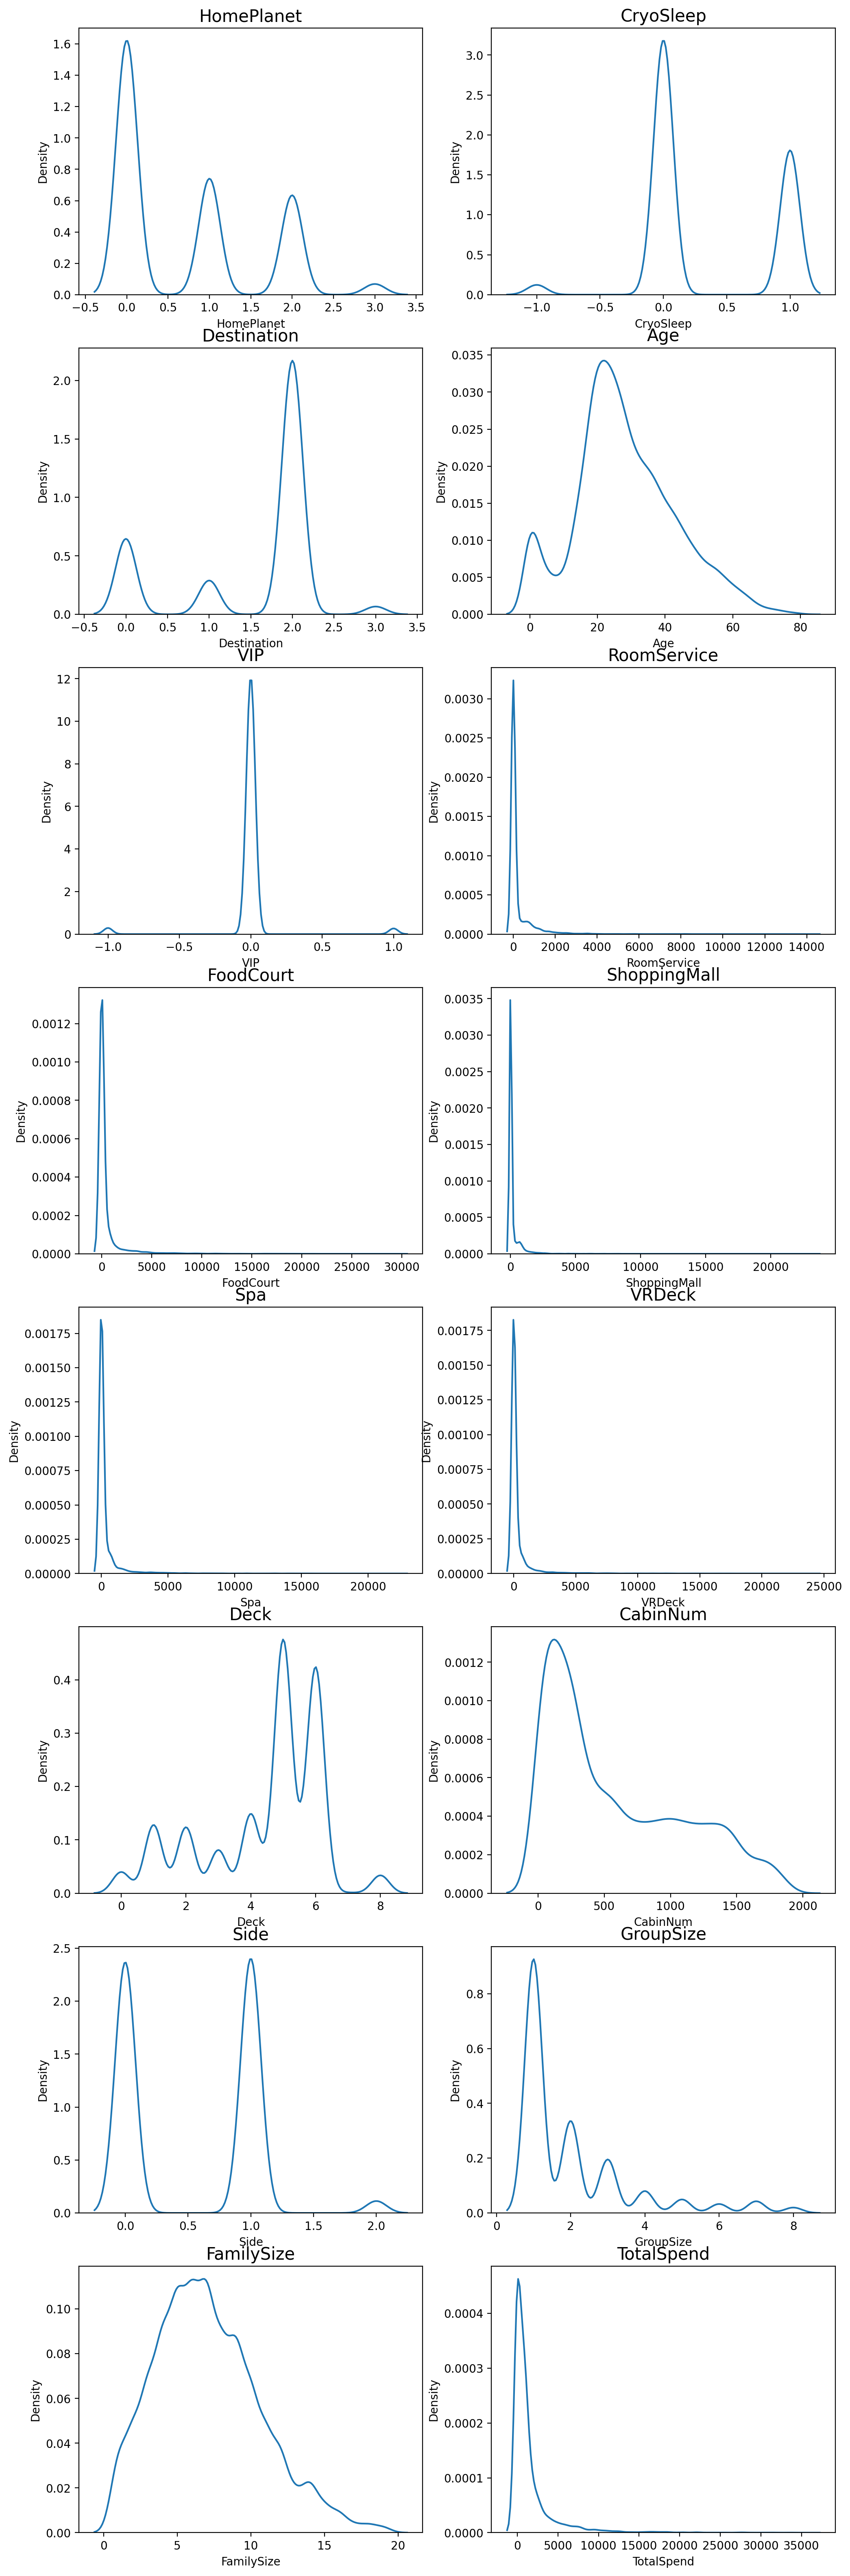

In [44]:
# 각 변수들의 분포 확인
# kdeplot은 이산(discrete) 데이터의 경우에도 부드러운 곡선으로
# 전체 분포를 확인할 수 있도록 하는 시각화 함수

fig, ax = plt.subplots(8, 2, figsize=(12, 40))   # 가로스크롤 때문에 그래프 확인이 불편하다면 figsize의 x값을 조절해 보세요.

# id 변수(count==0인 경우)는 제외하고 분포를 확인합니다.
count = 0
columns = data_copy.columns
for row in range(8):
    for col in range(2):
        sns.kdeplot(data=data_copy[columns[count]], ax=ax[row][col])
        ax[row][col].set_title(columns[count], fontsize=15)
        count += 1
        # if count == 16 :
        #     break

In [45]:
# 한쪽으로 치우친 경향 변수에 대해 로그 변환(log-scaling)을 통해 데이터 분포를 정규분포에 가깝게 변환
# numpy.log1p() 함수는 입력 배열의 각 요소에 대해
# 자연로그 log(1 + x)을 반환해 주는 함수

skew_columns = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend']

for c in skew_columns:
    data_copy[c] = np.log1p(data_copy[c].values)

print('얍💢')

얍💢


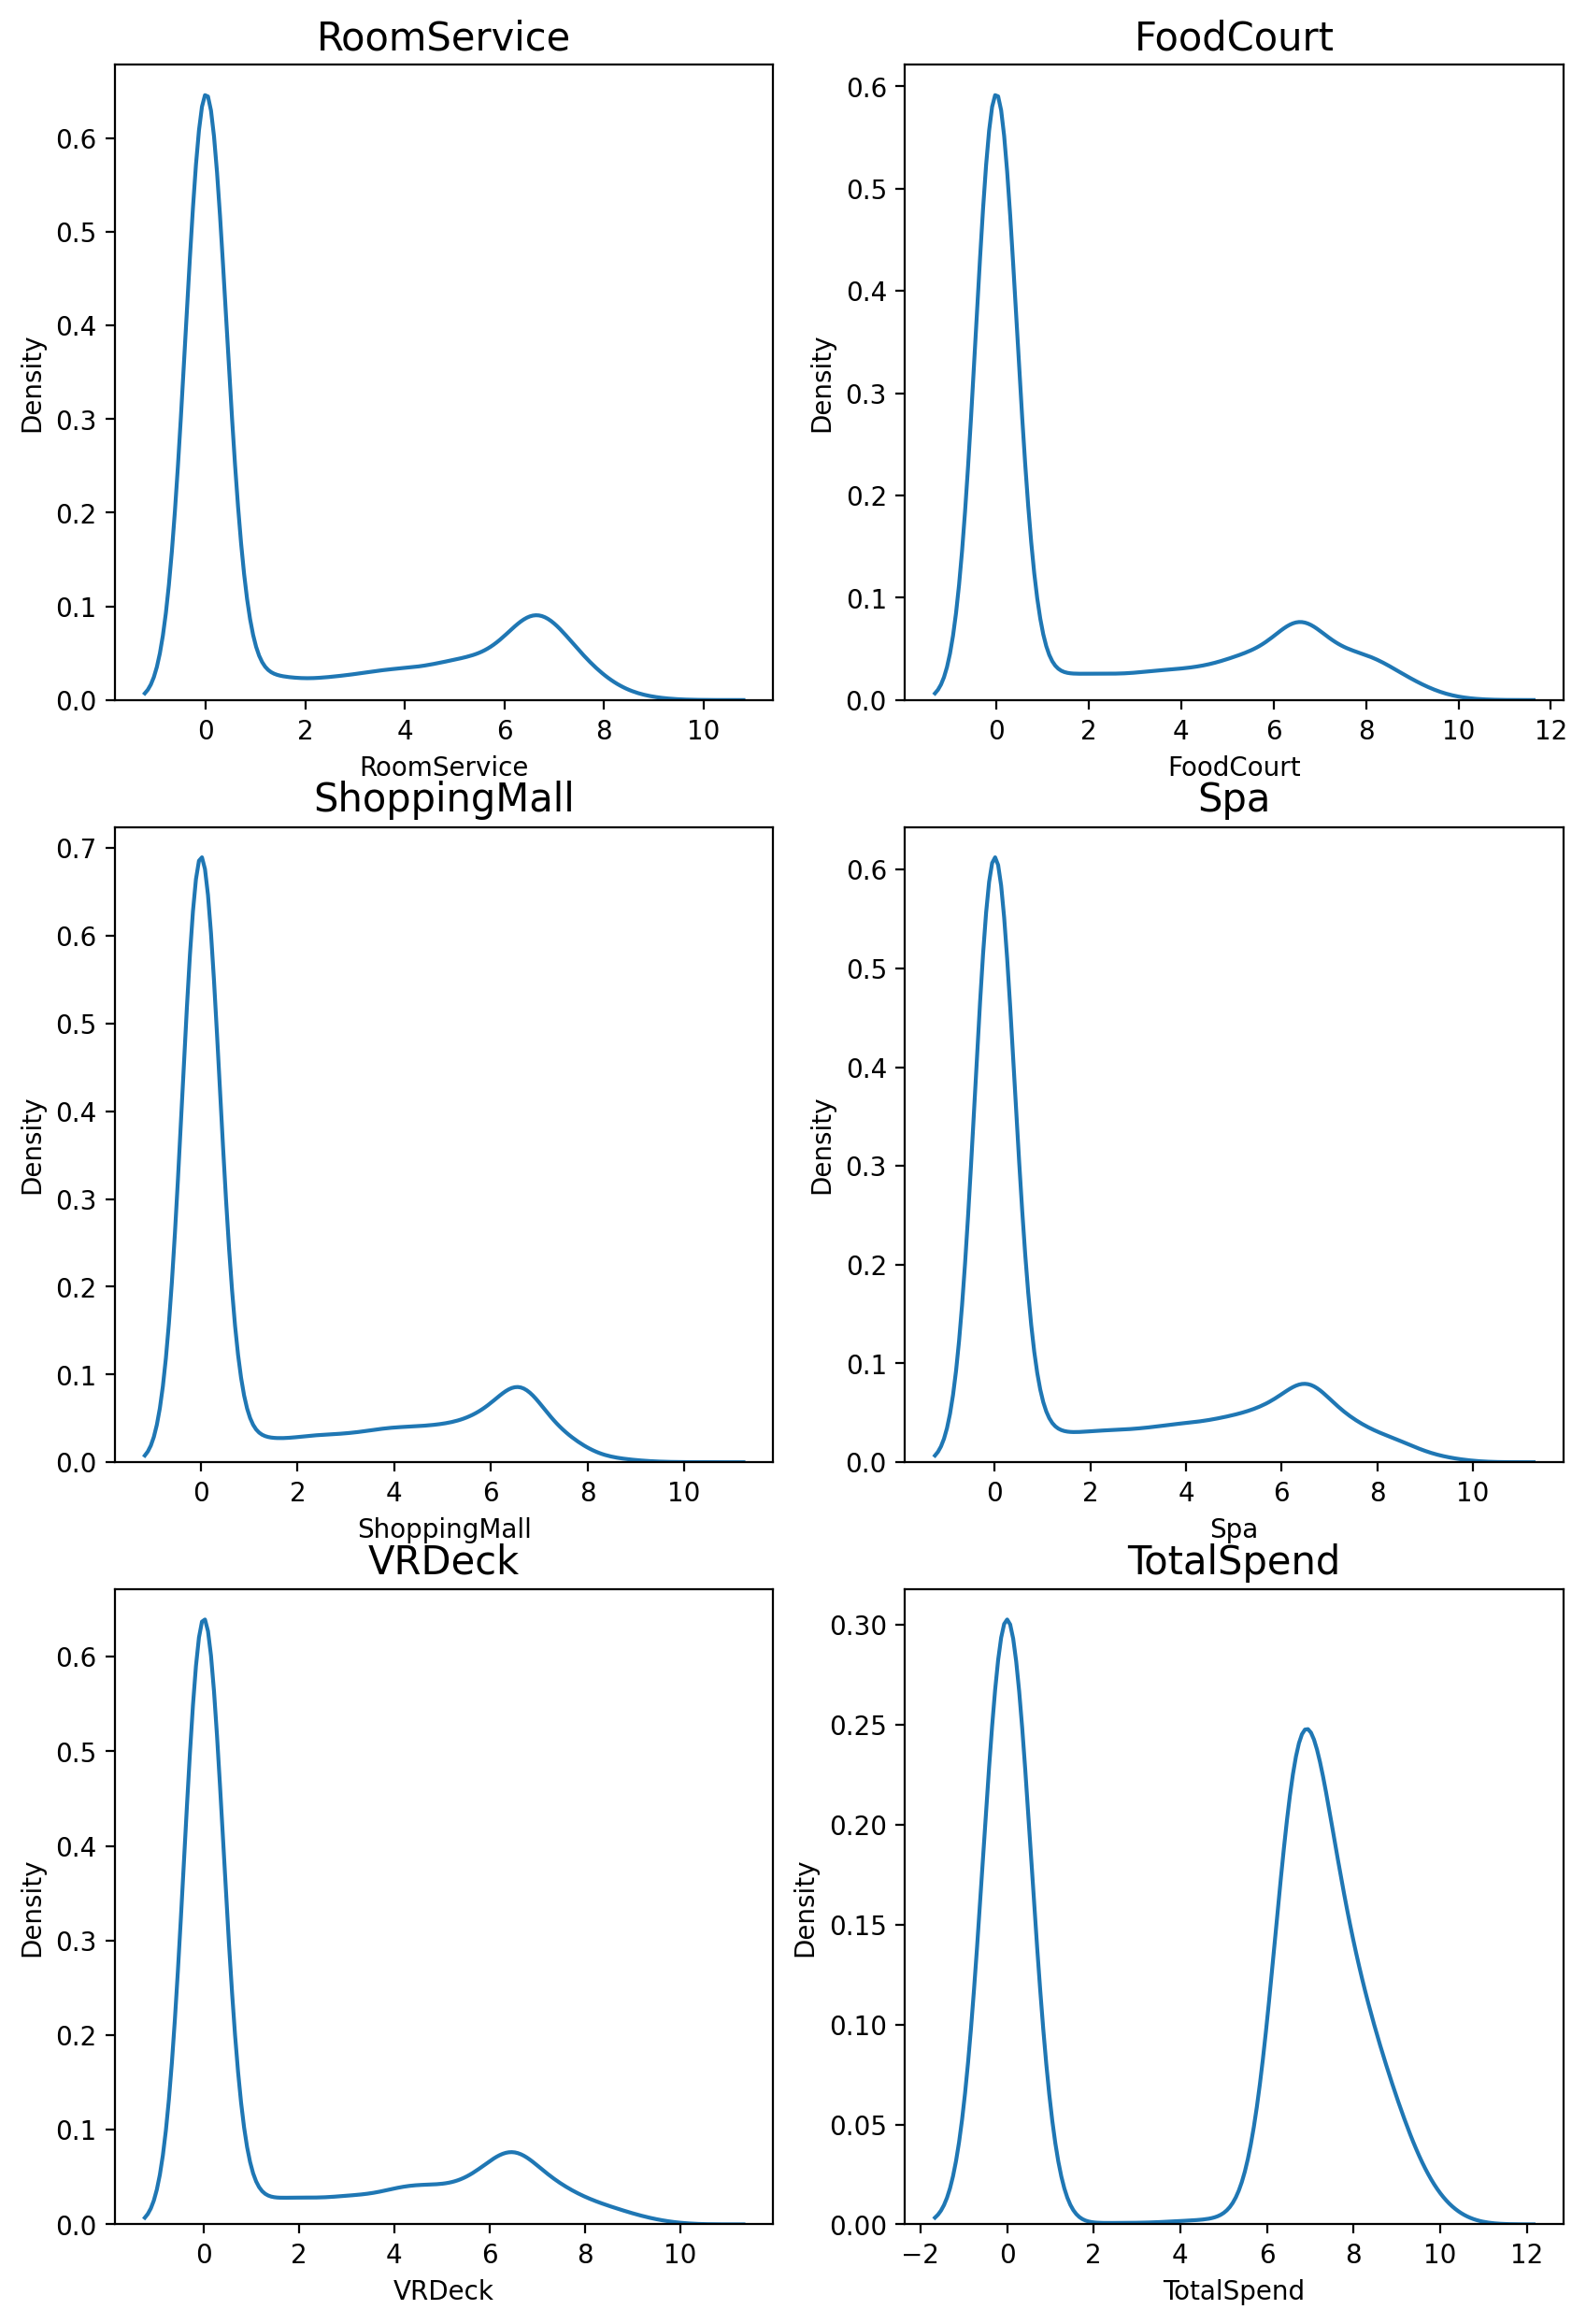

In [46]:
# 로그 변환 컬럼 분포 다시 확인

fig, ax = plt.subplots(3, 2, figsize=(10, 15))

count = 0
for row in range(3):
    for col in range(2):
        # if count == 5:
        #     break
        sns.kdeplot(data_copy[skew_columns[count]], ax=ax[row][col])
        ax[row][col].set_title(skew_columns[count], fontsize=15)
        count+=1

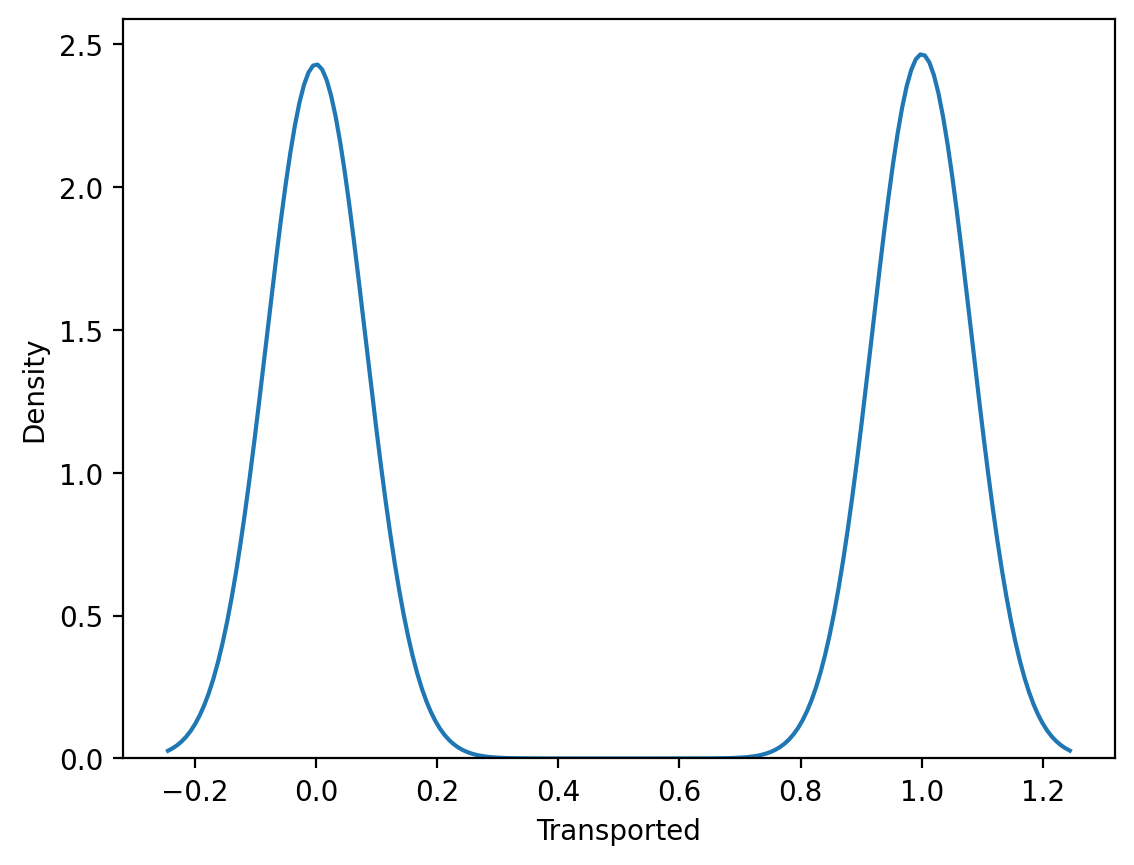

In [47]:
# targe (Transported)의 분포 (True, False)

sns.kdeplot(y)
plt.show()

In [48]:
# 전체 데이타 다시 분리

train_1 = data_copy.iloc[:train_len, :]    # 학습 데이터
test_1 = data_copy.iloc[train_len:, :]  # 테스트 데이터

print(train_1.shape)
print(test_1.shape)

(8693, 16)
(4277, 16)


# 3. 모델별 파라메터별 Test

## LGBMRegressor

### LGBMRegressor 함수

In [ ]:
# get_scores(models, train, y, random_state) 함수 생성
#
# 네 가지의 모델에 대해 모두 MSE값 저장

def get_scores_mse(models, train, y, random_state):
    df = {}

    for model in models:
        model_name = model.__class__.__name__

        X_train, X_test, y_train, y_test = train_test_split(train, y, random_state=random_state, test_size=0.2)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        df[model_name] = mean_squared_error(y_test, y_pred)
        score_df = pd.DataFrame(df, index=['MSE']).T.sort_values('MSE', ascending=False)

    return score_df

In [ ]:
# my_GridSearch_mse() 생성
#
# 1. GridSearchCV 모델로 `model`을 초기화합니다.
# 2. 모델을 fitting 합니다.
# 3. params, score에 각 조합에 대한 결과를 저장합니다.
# 4. 데이터 프레임을 생성하고, RMSLE 값을 추가한 후 점수가 높은 순서로 정렬한 `results`를 반환합니다.

def my_GridSearch_mse(model, train, y, param_grid, verbose=2, n_jobs=5, cv=5):

    # GridSearchCV 모델로 초기화
    grid_model = GridSearchCV(model, param_grid=param_grid, scoring='neg_mean_squared_error', \
                              cv=cv, verbose=verbose, n_jobs=n_jobs)

    # 모델 fitting
    grid_model.fit(train, y)

    # 결과값 저장
    params = grid_model.cv_results_['params']
    score = grid_model.cv_results_['mean_test_score']

    # 데이터 프레임 생성
    results = pd.DataFrame(params)
    results['score'] = score

    # MSE 값 계산 후 정렬
    results['MSE'] = -1 * results['score']
    results = results.sort_values('MSE')

    return results

In [ ]:
# save_submission_mse(model, train, y, test, model_name, mse) 생성
#
# 1. 모델을 `train`, `y`로 학습시킵니다.
# 2. `test`에 대해 예측합니다.
# 3. 예측값을 `np.expm1`으로 변환하고, `submission_model_name_RMSLE_100000.csv` 형태의 `csv` 파일을 저장합니다.

def save_submission_mse(model, train, y, test, model_name, mse=None):
    model.fit(train, y)
    prediction = model.predict(test)
    submission_path = 'sample_submission.csv'
    submission = pd.read_csv(submission_path)
    submission['Transported'] = prediction
    submission_csv_path = 'submission_{}_MSE_{}.csv'.format(model_name, mse)
    submission.to_csv(submission_csv_path, index=False)
    print('{} saved!'.format(submission_csv_path))

### 모델 체크

In [ ]:
#  models에 test 모델들 저장
#
random_state=2020

gboost = GradientBoostingRegressor(random_state=random_state)
xgboost = XGBRegressor(random_state=random_state)
lightgbm = LGBMRegressor(random_state=random_state)
rdforest = RandomForestRegressor(random_state=random_state)
lgmclass = LGBMClassifier(random_state=random_state)

models = [gboost, xgboost, lightgbm, rdforest,lgmclass]

models

[GradientBoostingRegressor(random_state=2020),
 XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...),
 LGBMRegressor(random_state=2020),
 RandomForestRegressor(random_state=2020),
 LGBMClassifier(random_state=2020)]

In [ ]:
# 모델별 score

score_df = get_scores_mse(models, train_1, y, random_state)
score_df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001183 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1918
[LightGBM] [Info] Number of data points in the train set: 6954, number of used features: 16
[LightGBM] [Info] Start training from score 0.502445
[LightGBM] [Info] Number of positive: 3494, number of negative: 3460
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001321 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1918
[LightGBM] [Info] Number of data points in the train set: 6954, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502445 -> initscore=0.009779
[LightGBM] [Info] Start training from score 0.009779


,MSE
LGBMClassifier,0.174813
XGBRegressor,0.135893
RandomForestRegressor,0.132280
GradientBoostingRegressor,0.127411
LGBMRegressor,0.121431


In [ ]:
# 경고 숨기기
import warnings
warnings.filterwarnings('ignore')

### LGBMRegressor 에 대해 파라메터 튜닝

In [ ]:

param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [10, 12],
    'num_leaves': [31],
    'subsample': [1.0]
}

model = LGBMRegressor(random_state=random_state)

result1 = my_GridSearch_mse(model, train_1, y, param_grid, verbose=0, n_jobs=5, cv=3)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001396 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1919
[LightGBM] [Info] Number of data points in the train set: 8693, number of used features: 16
[LightGBM] [Info] Start training from score 0.503624


In [ ]:
result1

,learning_rate,max_depth,n_estimators,num_leaves,subsample,score,MSE
3,0.05,12,100,31,1.0,-0.138494,0.138494
4,0.10,10,50,31,1.0,-0.138754,0.138754
1,0.05,10,100,31,1.0,-0.139191,0.139191
6,0.10,12,50,31,1.0,-0.139655,0.139655
7,0.10,12,100,31,1.0,-0.141202,0.141202
5,0.10,10,100,31,1.0,-0.141268,0.141268
2,0.05,12,50,31,1.0,-0.141838,0.141838
0,0.05,10,50,31,1.0,-0.142199,0.142199


In [ ]:

param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.05],
    'max_depth': [12],
    'num_leaves': [31, 63],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0]
}

model = LGBMRegressor(random_state=random_state)

result2 = my_GridSearch_mse(model, train_1, y, param_grid, verbose=0, n_jobs=5, cv=3)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001659 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1919
[LightGBM] [Info] Number of data points in the train set: 8693, number of used features: 16
[LightGBM] [Info] Start training from score 0.503624


In [ ]:
result2


,colsample_bytree,learning_rate,max_depth,n_estimators,num_leaves,subsample,score,MSE
0,0.70,0.05,12,100,31,0.70,-0.137596,0.137596
1,0.70,0.05,12,100,31,0.85,-0.137596,0.137596
2,0.70,0.05,12,100,31,1.00,-0.137596,0.137596
3,0.70,0.05,12,100,63,0.70,-0.137860,0.137860
4,0.70,0.05,12,100,63,0.85,-0.137860,0.137860
5,0.70,0.05,12,100,63,1.00,-0.137860,0.137860
6,0.85,0.05,12,100,31,0.70,-0.138410,0.138410
7,0.85,0.05,12,100,31,0.85,-0.138410,0.138410
8,0.85,0.05,12,100,31,1.00,-0.138410,0.138410
14,1.00,0.05,12,100,31,1.00,-0.138494,0.138494


In [ ]:
param_grid = {
    'n_estimators': [100, 400, 800],
    'learning_rate': [0.03, 0.05, 0.07],
    'max_depth': [12, 14],
    'num_leaves': [31],
    'subsample': [0.7],
    'colsample_bytree': [0.7]
}

model = LGBMRegressor(random_state=random_state)

result3 = my_GridSearch_mse(model, train_1, y, param_grid, verbose=0, n_jobs=5, cv=3)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001754 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1919
[LightGBM] [Info] Number of data points in the train set: 8693, number of used features: 16
[LightGBM] [Info] Start training from score 0.503624


In [ ]:
result3

,colsample_bytree,learning_rate,max_depth,n_estimators,num_leaves,subsample,score,MSE
15,0.7,0.07,14,100,31,0.7,-0.136841,0.136841
9,0.7,0.05,14,100,31,0.7,-0.136914,0.136914
12,0.7,0.07,12,100,31,0.7,-0.136944,0.136944
6,0.7,0.05,12,100,31,0.7,-0.137596,0.137596
4,0.7,0.03,14,400,31,0.7,-0.138600,0.138600
1,0.7,0.03,12,400,31,0.7,-0.139193,0.139193
3,0.7,0.03,14,100,31,0.7,-0.139287,0.139287
0,0.7,0.03,12,100,31,0.7,-0.139308,0.139308
7,0.7,0.05,12,400,31,0.7,-0.140865,0.140865
10,0.7,0.05,14,400,31,0.7,-0.140893,0.140893


In [ ]:
param_grid = {
    'boosting_type': ['gbdt', 'rf', 'dart'],
    'n_estimators': [100],
    'learning_rate': [0.07],
    'max_depth': [14],
    'num_leaves': [31],
    'subsample': [0.7],
    'colsample_bytree': [0.7],
    'min_child_samples': [10, 20]
}

model = LGBMRegressor(random_state=random_state)

result4 = my_GridSearch_mse(model, train_1, y, param_grid, verbose=0, n_jobs=5, cv=5)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001545 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1919
[LightGBM] [Info] Number of data points in the train set: 8693, number of used features: 16
[LightGBM] [Info] Start training from score 0.503624


In [ ]:
result4

,boosting_type,colsample_bytree,learning_rate,max_depth,min_child_samples,n_estimators,num_leaves,subsample,score,MSE
0,gbdt,0.7,0.07,14,10,100,31,0.7,-0.129848,0.129848
1,gbdt,0.7,0.07,14,20,100,31,0.7,-0.130021,0.130021
5,dart,0.7,0.07,14,20,100,31,0.7,-0.136255,0.136255
4,dart,0.7,0.07,14,10,100,31,0.7,-0.137302,0.137302
3,rf,0.7,0.07,14,20,100,31,0.7,-0.144159,0.144159
2,rf,0.7,0.07,14,10,100,31,0.7,-0.144384,0.144384


In [ ]:
param_grid = {
    'boosting_type': ['gbdt'],
    'n_estimators': [80, 100, 120],
    'learning_rate': [0.06, 0.07, 0.08],
    'max_depth': [14],
    'num_leaves': [31],
    'subsample': [0.7],
    'colsample_bytree': [0.7],
    'min_child_samples': [10]
}

model = LGBMRegressor(random_state=random_state)

result5 = my_GridSearch_mse(model, train_1, y, param_grid, verbose=0, n_jobs=5, cv=5)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001269 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1919
[LightGBM] [Info] Number of data points in the train set: 8693, number of used features: 16
[LightGBM] [Info] Start training from score 0.503624


In [ ]:
result5

,boosting_type,colsample_bytree,learning_rate,max_depth,min_child_samples,n_estimators,num_leaves,subsample,score,MSE
2,gbdt,0.7,0.06,14,10,120,31,0.7,-0.129811,0.129811
4,gbdt,0.7,0.07,14,10,100,31,0.7,-0.129848,0.129848
1,gbdt,0.7,0.06,14,10,100,31,0.7,-0.129859,0.129859
3,gbdt,0.7,0.07,14,10,80,31,0.7,-0.129888,0.129888
5,gbdt,0.7,0.07,14,10,120,31,0.7,-0.129925,0.129925
7,gbdt,0.7,0.08,14,10,100,31,0.7,-0.130351,0.130351
8,gbdt,0.7,0.08,14,10,120,31,0.7,-0.130387,0.130387
6,gbdt,0.7,0.08,14,10,80,31,0.7,-0.130411,0.130411
0,gbdt,0.7,0.06,14,10,80,31,0.7,-0.130540,0.130540


### LGBMRegressor 과적합 검증

In [ ]:
# 과적합 검증

kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

train_mse = []
val_mse = []

for train_idx, val_idx in kf.split(train_1):
    X_tr, X_va = train_1.iloc[train_idx], train_1.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

    model = LGBMRegressor(
      boosting_type = 'gbdt',
      n_estimators = 120,
      learning_rate = 0.06,
      max_depth = 14,
      num_leaves = 31,
      subsample = 0.7,
      colsample_bytree = 0.7,
      min_child_samples = 10,
      random_state=random_state
    )

    model.fit(X_tr, y_tr)

    # 예측
    tr_pred = model.predict(X_tr)
    va_pred = model.predict(X_va)

    # RMSLE
    train_mse.append(
        np.sqrt(mean_squared_error(y_tr, tr_pred))
    )
    val_mse.append(
        np.sqrt(mean_squared_error(y_va, va_pred))
    )

print(f"Train MSE (mean): {np.mean(train_mse):.4f}")
print(f"Val   MSE (mean): {np.mean(val_mse):.4f}")
print(f"Gap                : {np.mean(val_mse) - np.mean(train_mse):.4f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001424 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1918
[LightGBM] [Info] Number of data points in the train set: 6954, number of used features: 16
[LightGBM] [Info] Start training from score 0.502445
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001597 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1917
[LightGBM] [Info] Number of data points in the train set: 6954, number of used features: 16
[LightGBM] [Info] Start training from score 0.503883
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001370 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

In [ ]:
# 과적합 같음 (Gap ≤ 0.02 → 아주 건강, 0.02 ~ 0.05 → 살짝 과적합, > 0.05 → 과적합 확실)

## LGBMClassifier

In [51]:
random_state = 2020

model_lgbmclass = LGBMClassifier(
    objective='binary',
    random_state=random_state,
    n_jobs=-1
)

In [ ]:
param_grid = {   # 1차 GridSearchCV 용
    'n_estimators': [500, 1000],
    'learning_rate': [0.03, 0.05],
    'num_leaves': [31, 63],
}

In [ ]:
from sklearn.model_selection import StratifiedKFold  # 이진 분류여서 사용

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state
)

In [ ]:
# GridSearchCV 실행

grid_model = GridSearchCV(
    estimator=model_lgbmclass,
    param_grid=param_grid,
    scoring='accuracy',        # 또는 'roc_auc'
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_model.fit(train_1, y)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[LightGBM] [Info] Number of positive: 4378, number of negative: 4315
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1919
[LightGBM] [Info] Number of data points in the train set: 8693, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503624 -> initscore=0.014495
[LightGBM] [Info] Start training from score 0.014495


GridSearchCV(cv=3,
             estimator=LGBMClassifier(n_jobs=-1, objective='binary',
                                      random_state=2020),
             n_jobs=-1,
             param_grid={'learning_rate': [0.03, 0.05],
                         'n_estimators': [500, 1000], 'num_leaves': [31, 63]},
             scoring='accuracy', verbose=2)

In [ ]:
best_params_1 = grid_model.best_params_
print(best_params_1)

{'learning_rate': 0.03, 'n_estimators': 500, 'num_leaves': 31}


In [ ]:
# GridSearchCV 2차 (나누어서 진행)

param_grid = {
    'n_estimators': [500],
    'learning_rate': [0.03],
    'max_depth': [-1, 8, 10],
    'num_leaves': [31],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

grid_model = GridSearchCV(
    estimator=model_lgbmclass,
    param_grid=param_grid,
    scoring='accuracy',        # 또는 'roc_auc' 불균형 데이타
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_model.fit(train_1, y)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[LightGBM] [Info] Number of positive: 4378, number of negative: 4315
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001358 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1919
[LightGBM] [Info] Number of data points in the train set: 8693, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503624 -> initscore=0.014495
[LightGBM] [Info] Start training from score 0.014495


GridSearchCV(cv=3,
             estimator=LGBMClassifier(n_jobs=-1, objective='binary',
                                      random_state=2020),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.9],
                         'learning_rate': [0.03], 'max_depth': [-1, 8, 10],
                         'n_estimators': [500], 'num_leaves': [31],
                         'subsample': [0.7, 0.9]},
             scoring='accuracy', verbose=2)

In [ ]:
best_params_1 = grid_model.best_params_
print(best_params_1)

{'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': -1, 'n_estimators': 500, 'num_leaves': 31, 'subsample': 0.7}


In [ ]:
# test data에 모델 적용

best_model = grid_model.best_estimator_

test_pred = best_model.predict(test_1)
test_proba = best_model.predict_proba(test_1)[:, 1]


In [ ]:
test_pred = (test_proba > 0.5).astype(int)
test_pred_bool = test_pred.astype(bool)
test_pred_bool

array([ True, False,  True, ...,  True,  True,  True])

# 4. 결과 제출

## 1차 결과 (LGBMClasifier)

In [ ]:
# 파일로 제출

submission_path = 'sample_submission.csv'
submission = pd.read_csv(submission_path)
submission['Transported'] = test_pred_bool
submission

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,True
4274,9271_01,True
4275,9273_01,True


In [ ]:
submission_csv_path = 'submission_{}_{}.csv'.format("LGBMClassifier", "test2")
submission.to_csv(submission_csv_path, index=False)
print('{} saved!'.format(submission_csv_path))

submission_LGBMClassifier_test2.csv saved!


In [ ]:
# Kaggle 결과 : 0.80406

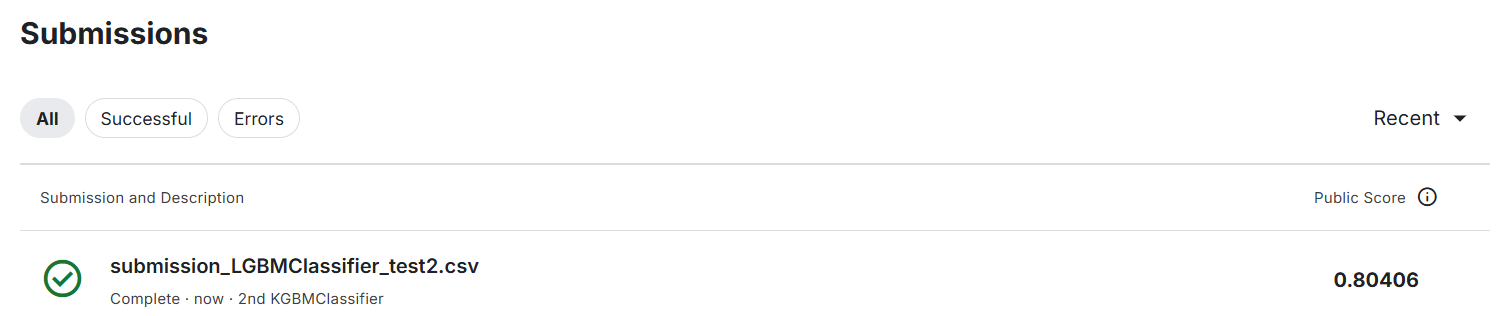

## 2차결과 (LGBMClasifier 에 대해 추가 파라메터 튜닝)

In [ ]:
#{'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': -1, 'n_estimators': 500, 'num_leaves': 31, 'subsample': 0.7}

param_grid_2 = {
    'n_estimators': [400],
    'learning_rate': [0.03],
    'max_depth': [-1, 8, 10],
    'num_leaves': [31, 63, 127],
    'subsample': [0.7],
    'colsample_bytree': [0.7],
    'min_child_samples': [10, 20, 40]
}

grid_model_2 = GridSearchCV(
    estimator=model_lgbmclass,
    param_grid=param_grid_2,
    scoring='accuracy',        # 또는 'roc_auc' 불균형 데이타
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_model_2.fit(train_1, y)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[LightGBM] [Info] Number of positive: 4378, number of negative: 4315
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001072 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1919
[LightGBM] [Info] Number of data points in the train set: 8693, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503624 -> initscore=0.014495
[LightGBM] [Info] Start training from score 0.014495
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

GridSearchCV(cv=5,
             estimator=LGBMClassifier(n_jobs=-1, objective='binary',
                                      random_state=2020),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7], 'learning_rate': [0.03],
                         'max_depth': [-1, 8, 10],
                         'min_child_samples': [10, 20, 40],
                         'n_estimators': [400], 'num_leaves': [31, 63, 127],
                         'subsample': [0.7]},
             scoring='accuracy', verbose=2)

In [ ]:
best_params_1 = grid_model_2.best_params_
print(best_params_1)

{'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 8, 'min_child_samples': 20, 'n_estimators': 400, 'num_leaves': 63, 'subsample': 0.7}


In [ ]:
# test data에 모델 적용

best_model = grid_model_2.best_estimator_

test_proba = best_model.predict_proba(test_1)[:, 1]
test_pred = (test_proba > 0.5).astype(int)
test_pred_bool = test_pred.astype(bool)
test_pred_bool

array([ True, False,  True, ...,  True,  True, False])

In [ ]:
# 파일로 제출

submission_path = 'sample_submission.csv'
submission = pd.read_csv(submission_path)
submission['Transported'] = test_pred_bool
submission_csv_path = 'submission_{}_{}.csv'.format("LGBMClassifier", "test4")
submission.to_csv(submission_csv_path, index=False)
print('{} saved!'.format(submission_csv_path))

submission_LGBMClassifier_test4.csv saved!


In [ ]:
# Kaggle 결과 : 0.80640  (1차보다 올라감)

## 3차결과 (LGBMClassifer 과적합 해소)

In [ ]:
#{'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': -1, 'n_estimators': 500, 'num_leaves': 31, 'subsample': 0.7}
#{'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 8, 'min_child_samples': 20, 'n_estimators': 400, 'num_leaves': 63, 'subsample': 0.7}

param_grid_3 = {
    'n_estimators': [400, 500, 700],
    'learning_rate': [0.03],
    'max_depth': [-1],
    'num_leaves': [31, 47],
    'subsample': [0.7],
    'colsample_bytree': [0.7],
    'min_child_samples': [20, 40]
}

grid_model_3 = GridSearchCV(
    estimator=model_lgbmclass,
    param_grid=param_grid_3,
    scoring='accuracy',        # 또는 'roc_auc' 불균형 데이타
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_model_3.fit(train_1, y)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 4378, number of negative: 4315
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005419 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1919
[LightGBM] [Info] Number of data points in the train set: 8693, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503624 -> initscore=0.014495
[LightGBM] [Info] Start training from score 0.014495


GridSearchCV(cv=5,
             estimator=LGBMClassifier(n_jobs=-1, objective='binary',
                                      random_state=2020),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7], 'learning_rate': [0.03],
                         'max_depth': [-1], 'min_child_samples': [20, 40],
                         'n_estimators': [400, 500, 700],
                         'num_leaves': [31, 47], 'subsample': [0.7]},
             scoring='accuracy', verbose=2)

In [ ]:
best_params_1 = grid_model_3.best_params_
print(best_params_1)

{'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 400, 'num_leaves': 31, 'subsample': 0.7}


In [ ]:
param_grid_3 = {
    'n_estimators': [400],
    'learning_rate': [0.03],
    'max_depth': [-1],
    'num_leaves': [31],
    'subsample': [0.7],
    'colsample_bytree': [0.7],
    'min_child_samples': [20],
    'reg_alpha': [0, 0.1],       # 과적합 제거
    'reg_lambda': [0, 0.5, 1.0]  # 과적합 제거
}

grid_model_3 = GridSearchCV(
    estimator=model_lgbmclass,
    param_grid=param_grid_3,
    scoring='accuracy',        # 또는 'roc_auc' 불균형 데이타
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_model_3.fit(train_1, y)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[LightGBM] [Info] Number of positive: 4378, number of negative: 4315
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001005 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1919
[LightGBM] [Info] Number of data points in the train set: 8693, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503624 -> initscore=0.014495
[LightGBM] [Info] Start training from score 0.014495


GridSearchCV(cv=5,
             estimator=LGBMClassifier(n_jobs=-1, objective='binary',
                                      random_state=2020),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7], 'learning_rate': [0.03],
                         'max_depth': [-1], 'min_child_samples': [20],
                         'n_estimators': [400], 'num_leaves': [31],
                         'reg_alpha': [0, 0.1], 'reg_lambda': [0, 0.5, 1.0],
                         'subsample': [0.7]},
             scoring='accuracy', verbose=2)

In [ ]:
best_params_1 = grid_model_3.best_params_
print(best_params_1)

{'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 400, 'num_leaves': 31, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.7}


In [ ]:
# test data에 모델 적용

best_model = grid_model_3.best_estimator_

test_proba = best_model.predict_proba(test_1)[:, 1]
test_pred = (test_proba > 0.5).astype(int)
test_pred_bool = test_pred.astype(bool)
test_pred_bool

array([ True, False,  True, ...,  True,  True,  True])

In [ ]:
# 파일로 제출

submission_path = 'sample_submission.csv'
submission = pd.read_csv(submission_path)
submission['Transported'] = test_pred_bool
submission_csv_path = 'submission_{}_{}.csv'.format("LGBMClassifier", "test5")
submission.to_csv(submission_csv_path, index=False)
print('{} saved!'.format(submission_csv_path))

submission_LGBMClassifier_test5.csv saved!


## 4차 결과 (과적합 해소안되어서 더처리)

In [52]:
#{'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': -1, 'n_estimators': 500, 'num_leaves': 31, 'subsample': 0.7}
#{'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 8, 'min_child_samples': 20, 'n_estimators': 400, 'num_leaves': 63, 'subsample': 0.7}
#{'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 400, 'num_leaves': 31, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.7}

param_grid_4 = {
    'num_leaves': [31, 47],
    'max_depth': [-1],
    'n_estimators': [500, 700],
    'min_child_samples': [20, 40],
    'learning_rate': [0.03],
    'subsample': [0.7],
    'colsample_bytree': [0.7],
    'reg_alpha': [0.1],       # 과적합 제거
    'reg_lambda': [1.0]       # 과적합 제거
}

grid_model_4 = GridSearchCV(
    estimator=model_lgbmclass,
    param_grid=param_grid_4,
    scoring='accuracy',        # 또는 'roc_auc' 불균형 데이타
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_model_4.fit(train_1, y)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[LightGBM] [Info] Number of positive: 4378, number of negative: 4315
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001331 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1919
[LightGBM] [Info] Number of data points in the train set: 8693, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503624 -> initscore=0.014495
[LightGBM] [Info] Start training from score 0.014495


GridSearchCV(cv=5,
             estimator=LGBMClassifier(n_jobs=-1, objective='binary',
                                      random_state=2020),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7], 'learning_rate': [0.03],
                         'max_depth': [-1], 'min_child_samples': [20, 40],
                         'n_estimators': [500, 700], 'num_leaves': [31, 47],
                         'reg_alpha': [0.1], 'reg_lambda': [1.0],
                         'subsample': [0.7]},
             scoring='accuracy', verbose=2)

In [ ]:
# 가장 성능 좋았던 파라미터 조합

best_params_1 = grid_model_4.best_params_
print(best_params_1)

In [53]:
# 최고 성능

print("Best CV Score", grid_model_4.best_score_)

Best CV Score 0.7873053770172003


In [54]:
# 전체 Grid 결과 테이블로 보기

results = pd.DataFrame(grid_model_4.cv_results_)
results.sort_values('rank_test_score').head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_learning_rate,param_max_depth,param_min_child_samples,param_n_estimators,param_num_leaves,...,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2,11.742508,2.467637,0.161765,0.007479,0.7,0.03,-1,20,700,31,...,0.7,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.762507,0.759057,0.794710,0.825662,0.794591,0.787305,0.024462,1
0,7.854092,1.519050,0.108316,0.008296,0.7,0.03,-1,20,500,31,...,0.7,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.764807,0.757907,0.798160,0.823360,0.791715,0.787190,0.023696,2
1,11.718386,1.780904,0.147201,0.025262,0.7,0.03,-1,20,500,47,...,0.7,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.759632,0.758482,0.791834,0.829114,0.792865,0.786386,0.026045,3
5,10.503751,1.593785,0.143872,0.017809,0.7,0.03,-1,40,500,47,...,0.7,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.765382,0.752731,0.799310,0.822785,0.787112,0.785464,0.024747,4
7,16.175097,5.694386,0.223794,0.060760,0.7,0.03,-1,40,700,47,...,0.7,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.763657,0.754457,0.792409,0.826237,0.787687,0.784889,0.025104,5
3,14.732934,1.071069,0.232442,0.022403,0.7,0.03,-1,20,700,47,...,0.7,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.763657,0.756757,0.789534,0.825086,0.787687,0.784544,0.024029,6
4,8.289700,1.835862,0.115223,0.022804,0.7,0.03,-1,40,500,31,...,0.7,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.759057,0.756182,0.792984,0.822209,0.789988,0.784084,0.024382,7
6,12.218595,3.148391,0.269078,0.097338,0.7,0.03,-1,40,700,31,...,0.7,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.755032,0.756182,0.792984,0.821634,0.791139,0.783394,0.025136,8


In [55]:
# Fold별 분산 확인 (과적합 체크)
# std_test_score ↑ → 모델 불안정
# mean 높고 std 낮은 게 진짜 좋은 모델

results[['mean_test_score', 'std_test_score']] \
    .sort_values('mean_test_score', ascending=False) \
    .head(10)

,mean_test_score,std_test_score
2,0.787305,0.024462
0,0.787190,0.023696
1,0.786386,0.026045
5,0.785464,0.024747
7,0.784889,0.025104
3,0.784544,0.024029
4,0.784084,0.024382
6,0.783394,0.025136


In [56]:
# test data에 모델 적용

best_model = grid_model_4.best_estimator_  # Best 파라미터로 학습된 모델 객체

test_proba = best_model.predict_proba(test_1)[:, 1]
test_pred = (test_proba > 0.5).astype(int)
test_pred_bool = test_pred.astype(bool)
test_pred_bool

array([ True, False,  True, ...,  True,  True,  True])

In [57]:
# 파일로 제출

submission_path = 'sample_submission.csv'
submission = pd.read_csv(submission_path)
submission['Transported'] = test_pred_bool
submission_csv_path = 'submission_{}_{}.csv'.format("LGBMClassifier", "test6")
submission.to_csv(submission_csv_path, index=False)
print('{} saved!'.format(submission_csv_path))

submission_LGBMClassifier_test6.csv saved!


In [58]:
# Kaggel 결과 : 0.80360

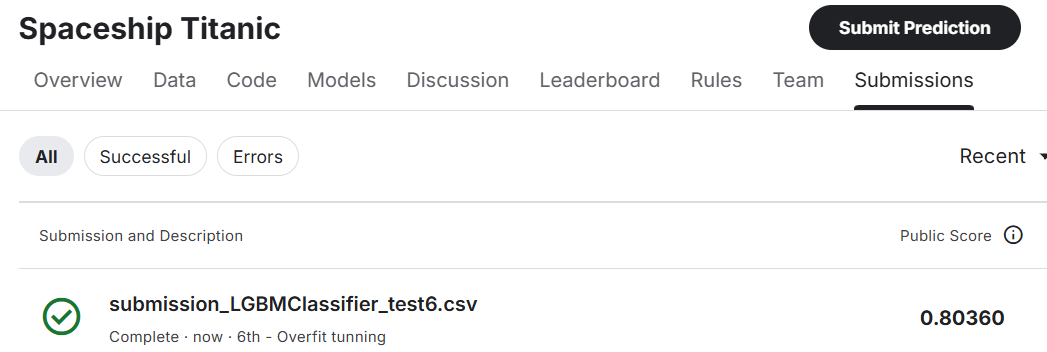

## 회고

- 이번 프로젝트를 하면서 느낀점, 배운점 : 데이타 분석에 대한 이해가 아직 기본도 안되어 있지만, 교재를 따라서 테스트하면서 배우고 있습니다. 과제의 깊이와 폭이 너무 넓은것 같아 배워야 할게 많이 있는것 같습니다.
- 이번 프로젝트에서 잘 했다고 생각이 드는 점 : 조금씩 조금씩 이해의 폭이 넓어지는것 같습니다. 그렇지만 아직 멀었습니다.
- 이번 프로젝트에서 느낀 문제점. : y 값을 보고 분류 문제로 바로 진행 했어야 하는데 회귀로 진행하다가 나중에 변경 했습니다.
- 다음에는 이렇게 해야겠다 생각한 점. : 조금 더 연습하고 공부하고 .. 좀더 노력하고자 합니다.

In [ ]:
# LGBMRegressor 은 점수가 안나와서 LGBMClassifer로 진행함
# model = LGBMRegressor(learning_rate = 0.06, max_depth=14, min_child_samples = 10, n_estimators=120, num_leaves = 31, boosting_type = 'gbdt', subsample = 0.7, colsample_bytree = 0.7,
#  	random_state=random_state)
# save_submission_mse(model, train_1, y, test_1, 'lgbm', mse='0.129811')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001702 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1919
[LightGBM] [Info] Number of data points in the train set: 8693, number of used features: 16
[LightGBM] [Info] Start training from score 0.503624
submission_lgbm_MSE_0.129811.csv saved!


In [ ]:
y

,Transported
0,False
1,True
2,False
3,False
4,True
...,...
8688,False
8689,False
8690,True
8691,False
